/var/folders/ks/l5k0stm95w5b5kn73hwp_8hc0000gn/T/ipykernel_42472/3807910367.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('NTDOY', period='max')
[*********************100%***********************]  1 of 1 completed


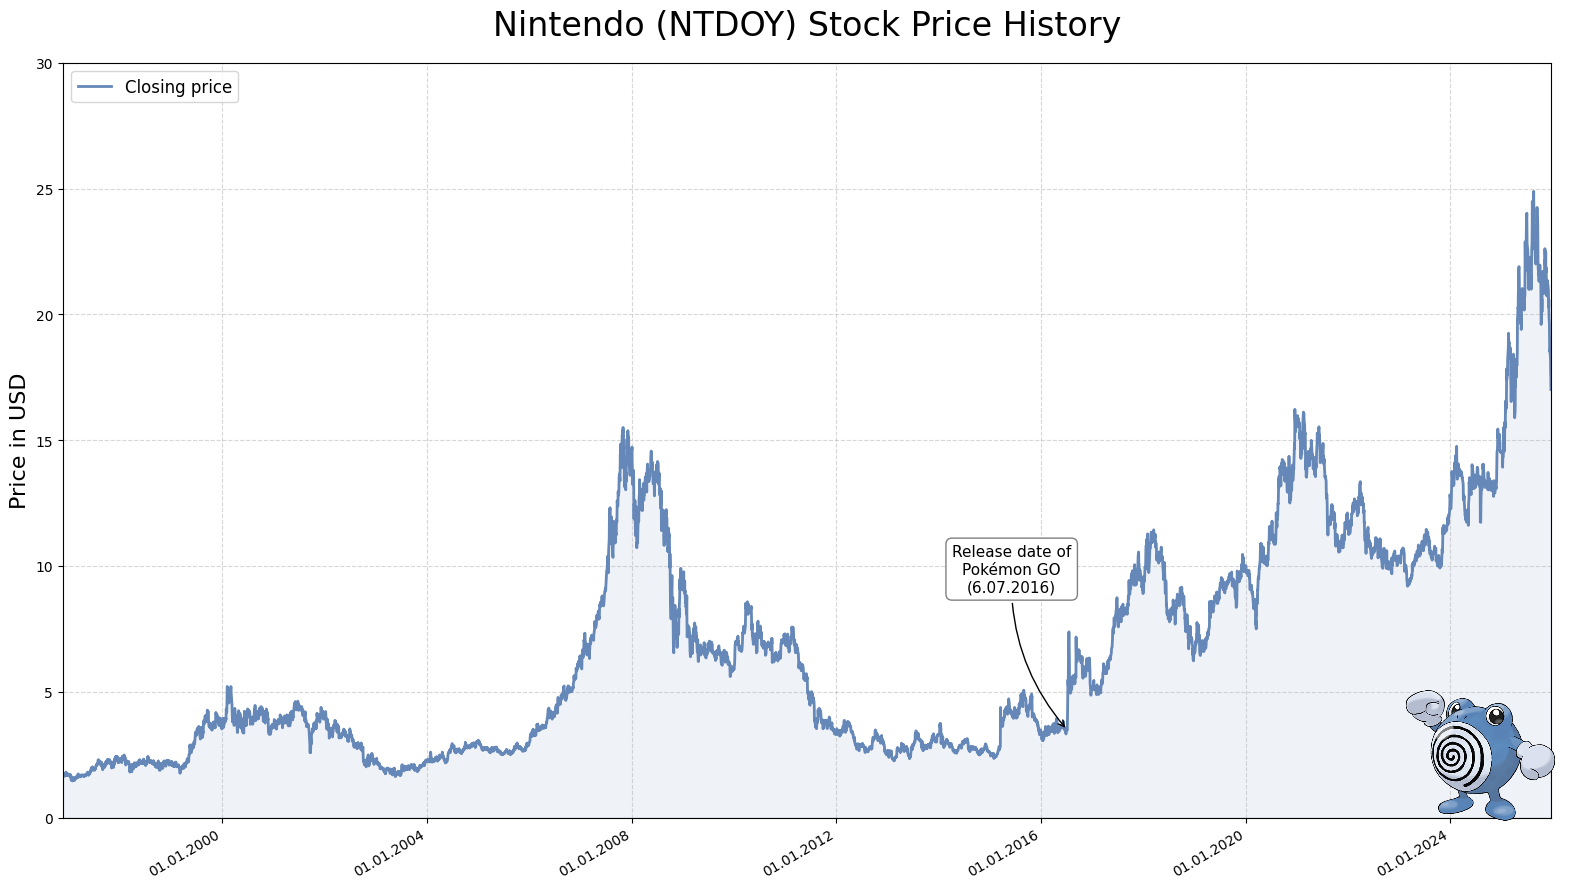

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.dates as mdates

#..pobieramy dane za pomocą yfinance - data ustawi się jako indeks
df = yf.download('NTDOY', period='max')
#..yfinance zwraca dataframe w 2D, a potrzebujemy series w 1D aby zastosować fill_between.  Użyjemy .squeeze()
close_price = df['Close'].squeeze() 

#..tworzenie wykresu
fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(df.index, close_price, color='#6588b8', linewidth=2, label='Closing price')
ax.fill_between(df.index, close_price, color='#6588b8', alpha=0.1)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper left')
ax.set_xlim(df.index.min(), df.index.max()) 
ax.set_ylim(0,30)

#..dodanie strzałki z dniem wydania gry mobilnej Pokemon GO
pogo_date = pd.Timestamp('2016-07-06')
price_at_date = close_price.asof(pogo_date)
ax.annotate(
    'Release date of\nPokémon GO\n(6.07.2016)', 
    xy=(pogo_date, price_at_date),          #..punkt w który celuje strzałka - (data, cena)
    xytext=(-40, 100),                      #..gdzie ma być położony tekst (przesunięcie od początku strzałki)
    textcoords='offset points',             #..interpreatacja xytext jako przesunięcia od początku strzałki
    arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3,rad=.2"),
    fontsize=11,
    ha='center', 
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray")
)

#..dodawanie pokemona do wykresu - Poliwhirl
img = plt.imread('images/images/61.png')
imagebox = OffsetImage(img, zoom=0.25) 
#..oś x to daty -> punkt na współrzędnej X pd.Timestamp
ab = AnnotationBbox(imagebox, xy=(pd.Timestamp('2024-08-01'), 2.45), frameon=False) 
ax.add_artist(ab) 

#..dodawanie opisu osi
ax.set_title('Nintendo (NTDOY) Stock Price History', fontsize=24, pad=20)
ax.set_ylabel('Price in USD', fontsize=16)

#..ustawienie formatu daty na label osi x 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
#..przechylenie dat o 30 stopni względem osi OX, zakotwiczenie daty do punktu po prawej stronie
fig.autofmt_xdate(ha='right', rotation=30)

plt.tight_layout()
plt.savefig('nintendo.png')
plt.show()